# Feature Engineering
### **Mohon membaca setiap instruksi dan tag komentar dengan saksama sebelum melanjutkan pengerjaan.**

Pada tahap awal dilakukan import beberapa library yang akan digunakan dalam proses analisis data. 
Library pandas digunakan untuk membaca dan mengelola dataset, sedangkan library lain digunakan 
untuk proses visualisasi dan preprocessing data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# B. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [2]:
# untuk plot Q-Q
import scipy.stats as stats

Dataset dibaca menggunakan fungsi read_csv() dari library pandas. 
Dataset yang digunakan dalam proses ini adalah california_dataset.csv 
yang nantinya akan digunakan untuk proses analisis distribusi data 
dan penanganan outlier.

In [3]:
df_california = pd.read_csv('california_dataset.csv')
df_california.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,house_price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Sebelum melakukan proses preprocessing, dataset terlebih dahulu 
dibagi menjadi data training dan data testing menggunakan 
fungsi train_test_split. 

Pembagian ini bertujuan agar proses preprocessing hanya dilakukan 
pada data training sehingga dapat menghindari terjadinya data leakage. 
Pada percobaan ini digunakan rasio pembagian data sebesar 80:20.

In [5]:
from sklearn.model_selection import train_test_split

train_clfr, test_clfr = train_test_split(
    df_california,
    test_size=0.2,
    random_state=42
)
# splitting terlebih dahulu

#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

### Assignment 1.a :
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

In [8]:
# Assignment 1.a : lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup'] di california_dataset.csv
# Daftar nama kolom yang ingin Anda cek
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

def check_plot(df, variable):
    # tentukan ukuran gambar
    plt.figure(figsize=(16,4))

    # Histogram
    plt.subplot(1,3,1)
    sns.histplot(df[variable], bins=30)
    plt.title('Histogram')

    # Q-Q Plot
    plt.subplot(1,3,2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.ylabel('Variable quantiles')

    # Boxplot
    plt.subplot(1,3,3)
    sns.boxplot(y=df[variable])
    plt.title('Boxplot')

    plt.show()

Selanjutnya dilakukan pengecekan distribusi data pada beberapa kolom 
menggunakan histogram, Q-Q plot, dan boxplot. Visualisasi ini bertujuan 
untuk melihat pola distribusi data serta mendeteksi kemungkinan adanya 
outlier pada setiap kolom.

Visualisasi untuk: MedInc


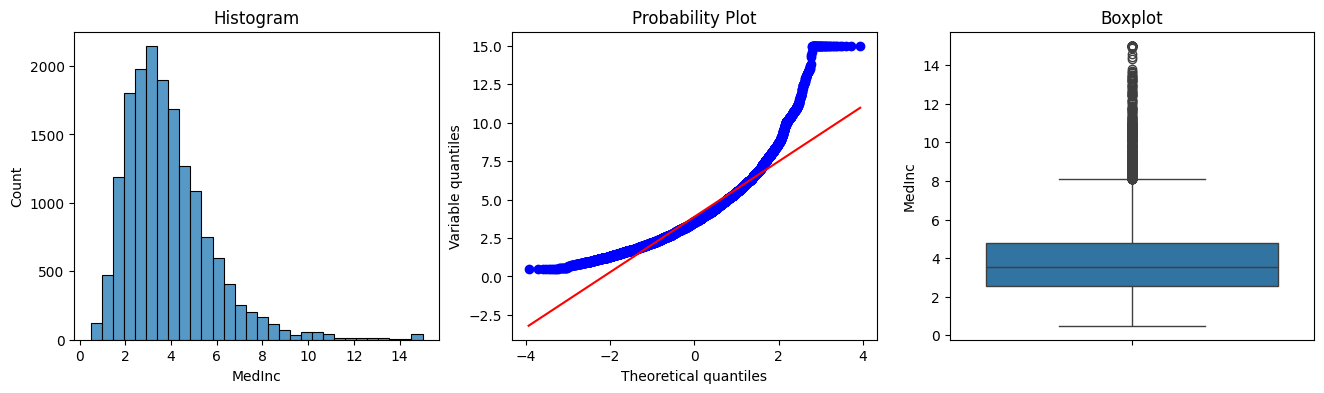

Visualisasi untuk: HouseAge


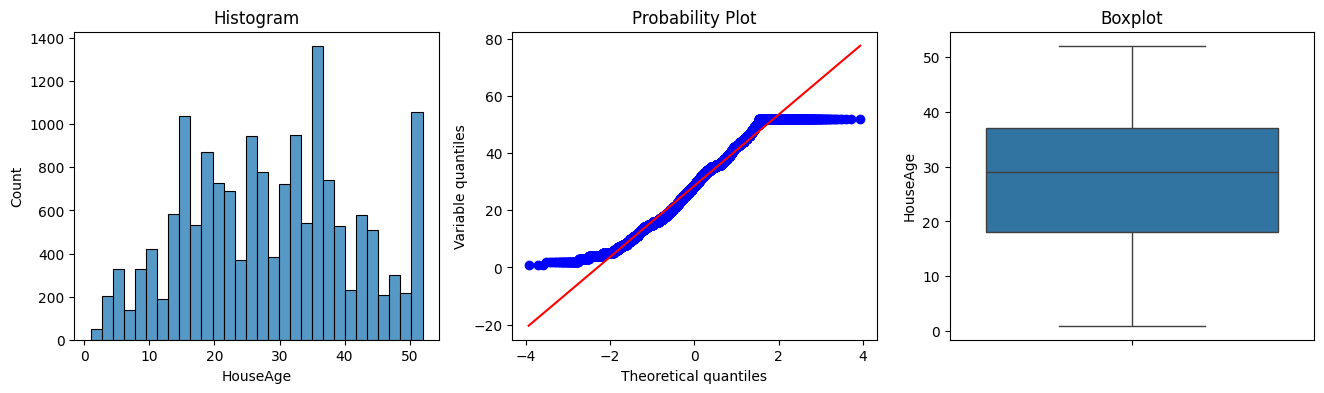

Visualisasi untuk: AveRooms


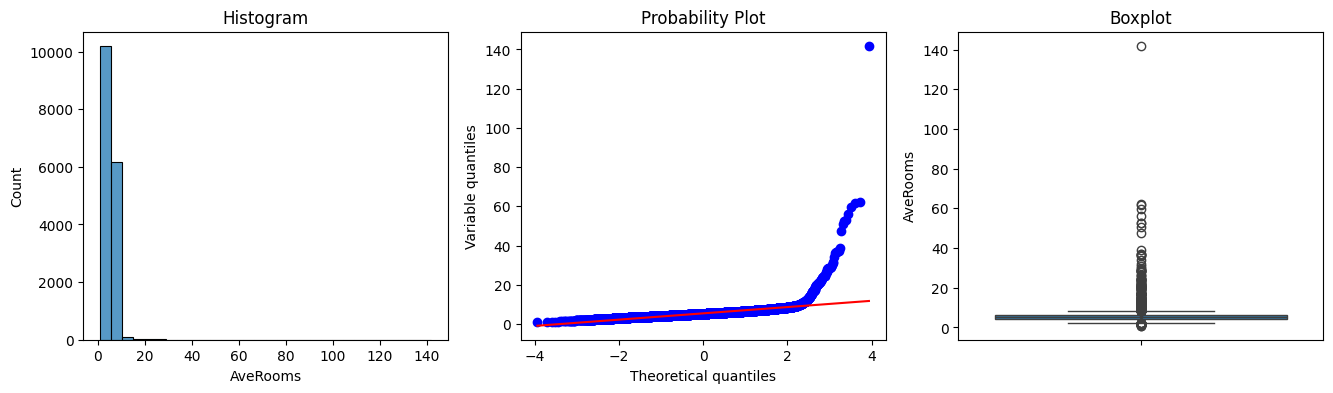

Visualisasi untuk: AveBedrms


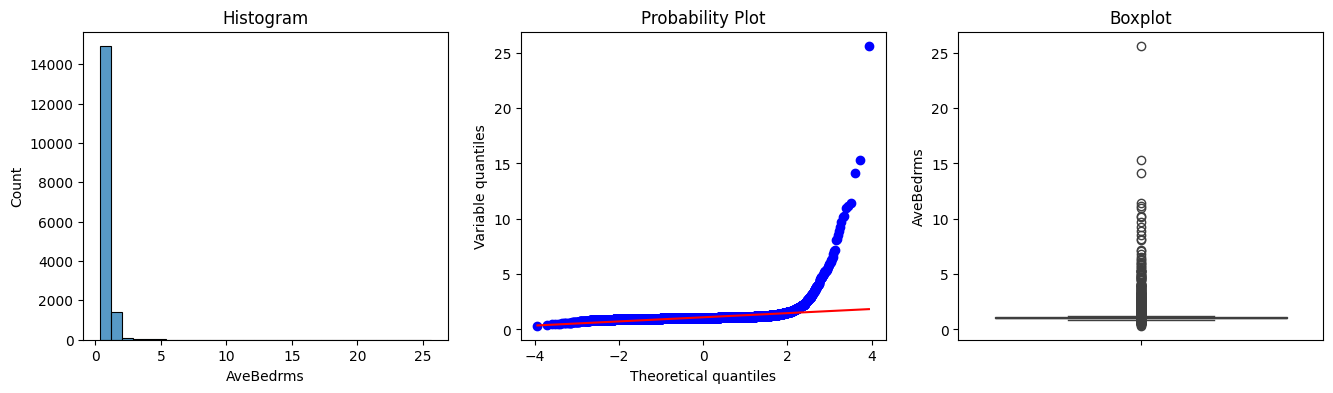

Visualisasi untuk: AveOccup


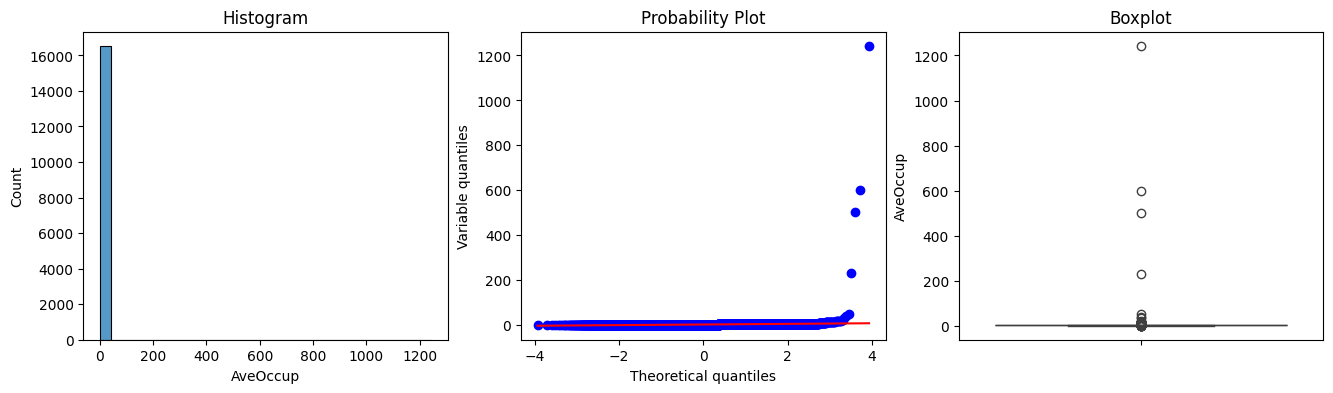

In [9]:
for kolom in kolom_kolom:
    print("Visualisasi untuk:", kolom)
    check_plot(train_clfr, kolom)

### Assignment 1.b
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali

Outlier ditangani menggunakan metode Interquartile Range (IQR). 
Metode ini bekerja dengan menghitung nilai kuartil pertama (Q1) 
dan kuartil ketiga (Q3), kemudian menentukan batas bawah dan batas 
atas untuk mendeteksi nilai yang dianggap sebagai outlier.

Nilai yang berada di luar batas tersebut akan dihapus dari dataset 
training agar distribusi data menjadi lebih stabil.

In [ ]:
### Assignment 1.b Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
### Dan cek distribusinya kembali
kolom = 'AveRooms'

Q1 = train_clfr[kolom].quantile(0.25)
Q3 = train_clfr[kolom].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

train_no_outlier = train_clfr[
    (train_clfr[kolom] >= lower_bound) &
    (train_clfr[kolom] <= upper_bound)
]

In [15]:
print("Jumlah data sebelum:", train_clfr.shape)
print("Jumlah data sesudah:", train_no_outlier.shape)

Jumlah data sebelum: (16512, 9)
Jumlah data sesudah: (16102, 9)


Distribusi untuk kolom: MedInc


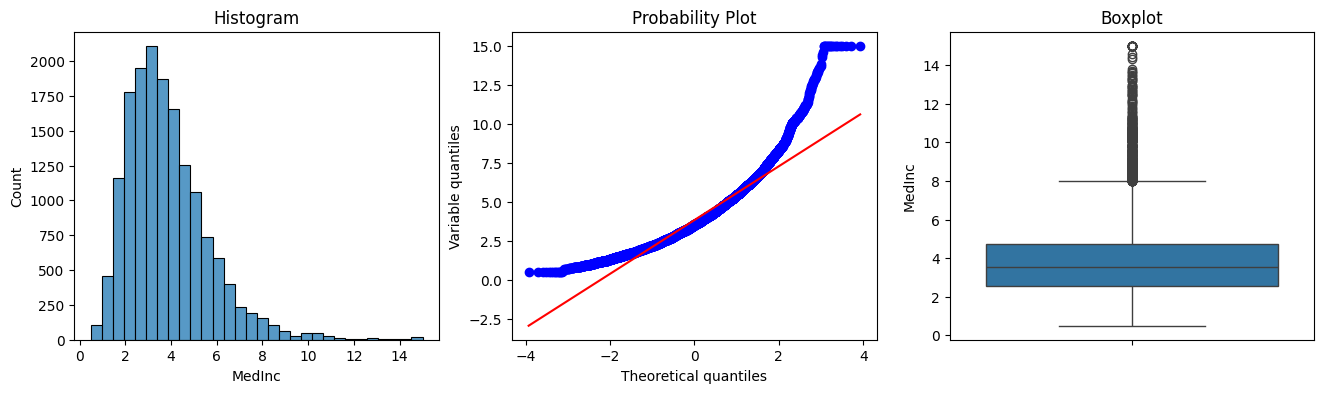

Distribusi untuk kolom: HouseAge


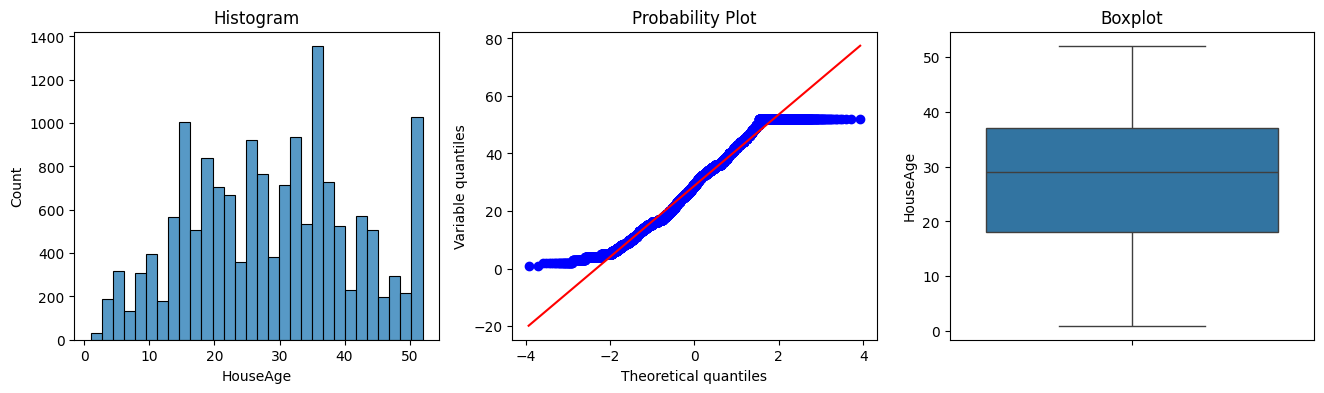

Distribusi untuk kolom: AveRooms


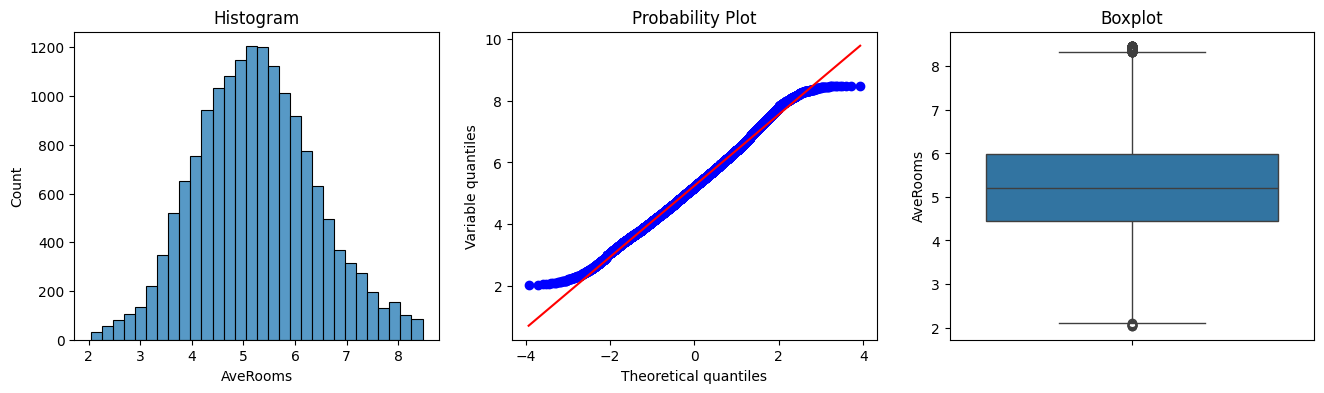

Distribusi untuk kolom: AveBedrms


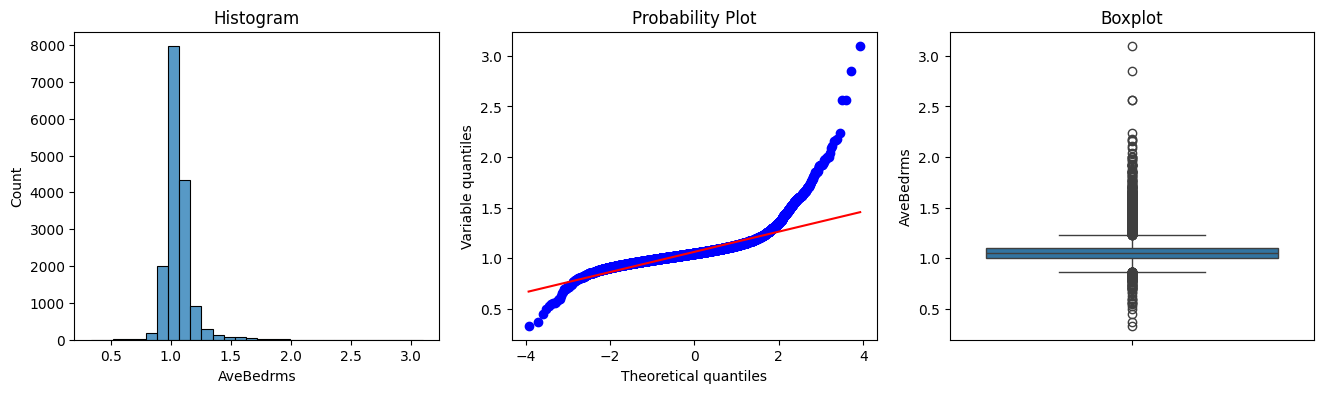

Distribusi untuk kolom: AveOccup


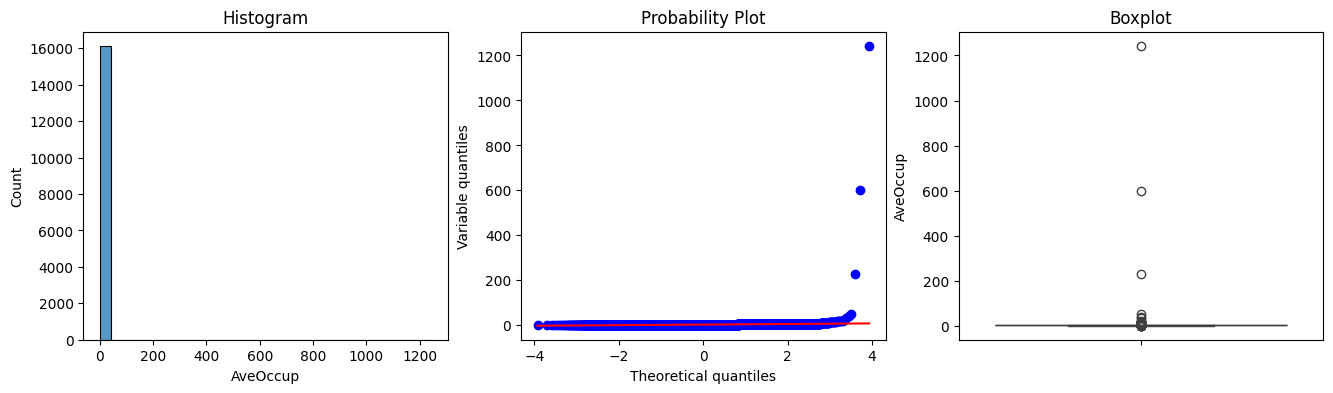

In [17]:
# Melakukan loop untuk mengecek distribusi tiap kolom
kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

for kolom in kolom_kolom:
    print("Distribusi untuk kolom:", kolom)
    check_plot(train_no_outlier, kolom)


# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

In [37]:
df_company = pd.read_csv('company.csv')
df_company.head()

,Revenue,Size,Rating,Headquarters
0,Unknown / Non-Applicable,1001 to 5000 employees,3.1,"New York, NY"
1,$1 to $2 billion (USD),5001 to 10000 employees,4.2,"Herndon, VA"
2,$100 to $500 million (USD),1001 to 5000 employees,3.8,"Boston, MA"
3,$100 to $500 million (USD),501 to 1000 employees,3.5,"Bad Ragaz, Switzerland"
4,Unknown / Non-Applicable,51 to 200 employees,2.9,"New York, NY"


In [38]:
df_company.isna().sum()

Revenue         0
Size            0
Rating          0
Headquarters    0
dtype: int64

In [ ]:
import pandas as pd

df_company = pd.read_csv('company.csv')
for column in df_company.columns:
    print(f"============= {column} =================")
    display(df_company[column].value_counts())
    print()

============= Revenue =================


Revenue
Unknown / Non-Applicable            213
$100 to $500 million (USD)           94
$10+ billion (USD)                   63
$2 to $5 billion (USD)               45
$10 to $25 million (USD)             41
$1 to $2 billion (USD)               36
$25 to $50 million (USD)             36
$50 to $100 million (USD)            31
$1 to $5 million (USD)               31
-1                                   27
$500 million to $1 billion (USD)     19
$5 to $10 million (USD)              14
Less than $1 million (USD)           14
$5 to $10 billion (USD)               8
Name: count, dtype: int64


============= Size =================


Size
51 to 200 employees        135
1001 to 5000 employees     104
1 to 50 employees           86
201 to 500 employees        85
10000+ employees            80
501 to 1000 employees       77
5001 to 10000 employees     61
-1                          27
Unknown                     17
Name: count, dtype: int64


============= Rating =================


Rating
 3.5    58
-1.0    50
 3.3    41
 4.0    41
 3.9    40
 3.8    39
 3.7    38
 5.0    36
 4.5    32
 3.6    31
 3.4    31
 4.2    29
 4.1    25
 4.4    24
 4.7    22
 3.2    21
 4.8    20
 2.9    14
 4.3    14
 3.1    12
 4.6    12
 4.9    11
 2.7    10
 3.0     7
 2.6     4
 2.8     3
 2.5     2
 2.2     1
 2.4     1
 2.3     1
 2.1     1
 2.0     1
Name: count, dtype: int64


============= Headquarters =================


Headquarters
New York, NY                 33
San Francisco, CA            31
-1                           31
Chicago, IL                  23
Boston, MA                   19
Reston, VA                   14
Mc Lean, VA                  13
Westminster, CO              12
Cambridge, MA                10
Cambridge, United Kingdom    10
Vienna, VA                    8
Herndon, VA                   7
Bedford, MA                   7
Saint Louis, MO               7
Washington, DC                7
Denver, CO                    7
Arlington, VA                 7
San Jose, CA                  7
Woodbine, MD                  7
Basel, Switzerland            6
Mountain View, CA             6
Chantilly, VA                 6
San Rafael, CA                6
San Antonio, TX               6
Princeton, NJ                 5
Bellevue, WA                  5
Rockville, MD                 5
Bethesda, MD                  5
Fairfax, VA                   5
Springfield, MA               5
Houston, TX                

### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [19]:
from sklearn.model_selection import train_test_split

train_company, test_company = train_test_split(
    df_company,
    test_size=0.2,
    random_state=42
)
#Splitting terlebih dahulu
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)

In [20]:
print("Jumlah data train:", train_company.shape)
print("Jumlah data test:", test_company.shape)

Jumlah data train: (537, 4)
Jumlah data test: (135, 4)


## Assignment 2. Missing Value Handling :
1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [21]:
#Tulis jawaban missing value handling kolom Headquarters disini
# cek jumlah missing value
missing = train_company['Headquarters'].isnull().sum()

# cek persentase missing value
persen_missing = train_company['Headquarters'].isnull().mean() * 100

print("Jumlah missing:", missing)
print("Persentase missing:", persen_missing, "%")

Jumlah missing: 0
Persentase missing: 0.0 %


In [22]:
train_company['Headquarters'].dtype

<StringDtype(storage='python', na_value=nan)>

In [23]:
if persen_missing > 20:
    print("Kolom di-drop")
else:
    print("Kolom tidak di-drop")

Kolom tidak di-drop


In [24]:
train_company['Headquarters'] = train_company['Headquarters'].fillna(
    train_company['Headquarters'].mode()[0]
)

In [25]:
train_company['Headquarters'].isnull().sum()

np.int64(0)

# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

In [29]:
df_churn = pd.read_csv('TelcoCustomerChurn.csv')
df_churn.head(6)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes


In [30]:
#Splitting terlebih dahulu
from sklearn.model_selection import train_test_split

train_churn, test_churn = train_test_split(
    df_churn,
    test_size=0.2,
    random_state=42
)

print(train_churn.shape)
print(test_churn.shape)


(5634, 21)
(1409, 21)


## Assignment 3.a Label Encoder :
1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csv

In [40]:
#Tulis jawaban
from sklearn.preprocessing import LabelEncoder
columns = [
    'StreamingMovies',
    'StreamingTV',
    'TechSupport',
    'DeviceProtection',
    'OnlineBackup',
    'OnlineSecurity',
    'MultipleLines'
]


Kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, 
OnlineBackup, OnlineSecurity, dan MultipleLines dipilih untuk 
dilakukan proses encoding.

Sebelum encoding dilakukan, nilai "No internet service" terlebih 
dahulu diganti menjadi "No" agar kategori menjadi konsisten. 
Setelah itu dilakukan proses Label Encoding untuk mengubah nilai 
kategorikal menjadi numerik.

In [33]:
for col in columns:
    train_churn[col] = train_churn[col].replace('No internet service', 'No')

In [34]:
for col in columns:
    print(col)
    print(train_churn[col].value_counts())
    print()

StreamingMovies
StreamingMovies
No     3437
Yes    2197
Name: count, dtype: int64

StreamingTV
StreamingTV
No     3453
Yes    2181
Name: count, dtype: int64

TechSupport
TechSupport
No     4005
Yes    1629
Name: count, dtype: int64

DeviceProtection
DeviceProtection
No     3703
Yes    1931
Name: count, dtype: int64

OnlineBackup
OnlineBackup
No     3662
Yes    1972
Name: count, dtype: int64

OnlineSecurity
OnlineSecurity
No     4024
Yes    1610
Name: count, dtype: int64

MultipleLines
MultipleLines
No                  2685
Yes                 2397
No phone service     552
Name: count, dtype: int64



In [35]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in columns:
    train_churn[col] = le.fit_transform(train_churn[col])

In [36]:
train_churn[columns].head()

,StreamingMovies,StreamingTV,TechSupport,DeviceProtection,OnlineBackup,OnlineSecurity,MultipleLines
2142,1,0,0,1,0,1,0
1623,1,1,0,0,1,0,2
6074,0,0,0,0,0,0,1
1362,0,0,0,0,0,0,0
6754,0,0,1,0,1,1,2


## Selesai :)